<a href="https://colab.research.google.com/github/MelB18/EasyQuanten/blob/main/Daenemark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Der erste Schritt ist gemacht.


In [2]:
# Install required packages.
# Uncomment the lines below the first time you run this notebook to install dependencies,
# then re-comment them on subsequent runs.


%pip install --upgrade 'qiskit[visualization]>=2.5.0' qiskit-aer qiskit-ibm-runtime matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.7/94.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6

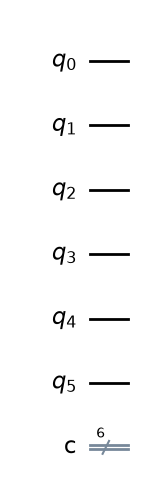

In [19]:
from qiskit import QuantumCircuit

gamma = 0.5
beta = 0.3

qc = QuantumCircuit(6, 6)

qc.draw("mpl")

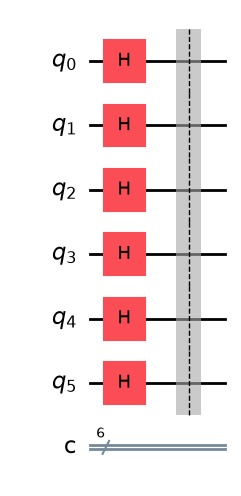

In [20]:
# ==========================================
# 1. Superposition
# ==========================================

for q in range(6):
  qc.h(q)

qc.barrier()

qc.draw("mpl")

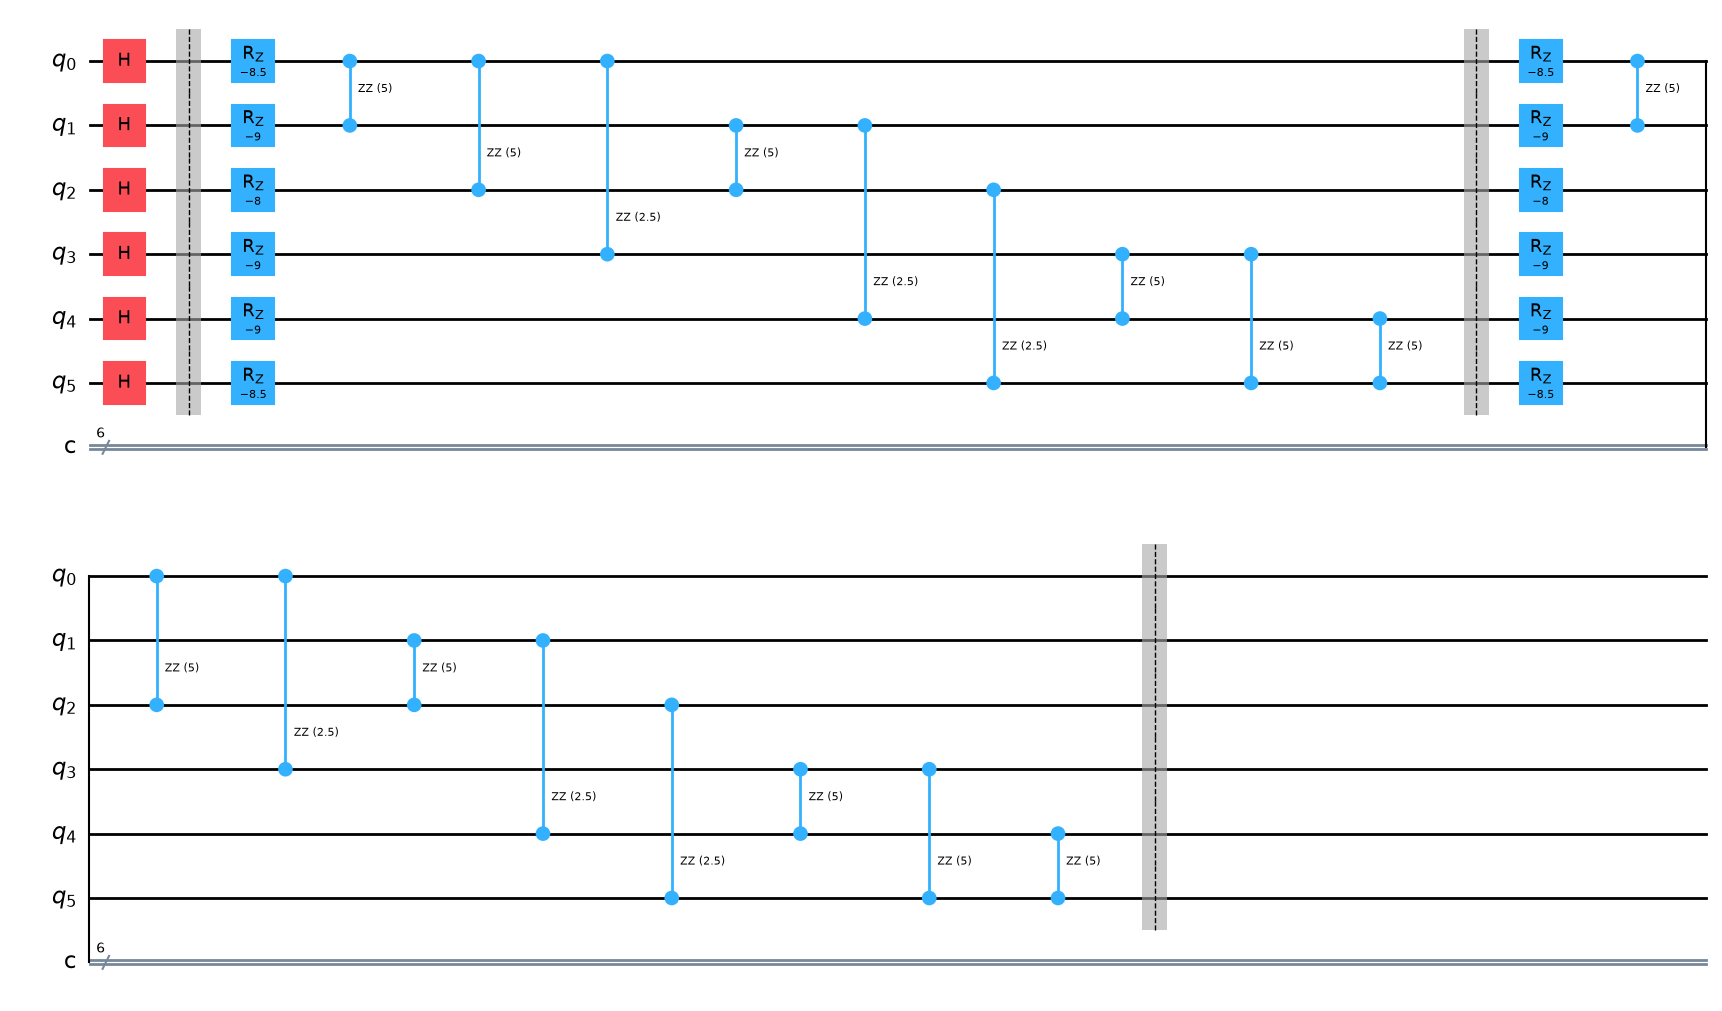

In [22]:
# ==========================================
# 2. Cost Layer
# ==========================================

h = [-8.5, -9.0, -8.0, -9.0, -9.0, -8.5]

for q, coeff in enumerate(h):
  qc.rz(2 * gamma * coeff, q)

zz_terms = [
(0, 1, 5.0),
(0, 2, 5.0),
(0, 3, 2.5),
(1, 2, 5.0),
(1, 4, 2.5),
(2, 5, 2.5),
(3, 4, 5.0),
(3, 5, 5.0),
(4, 5, 5.0),
]

for q1, q2, coeff in zz_terms:
  qc.rzz(2 * gamma * coeff, q1, q2)

qc.barrier()

qc.draw("mpl")

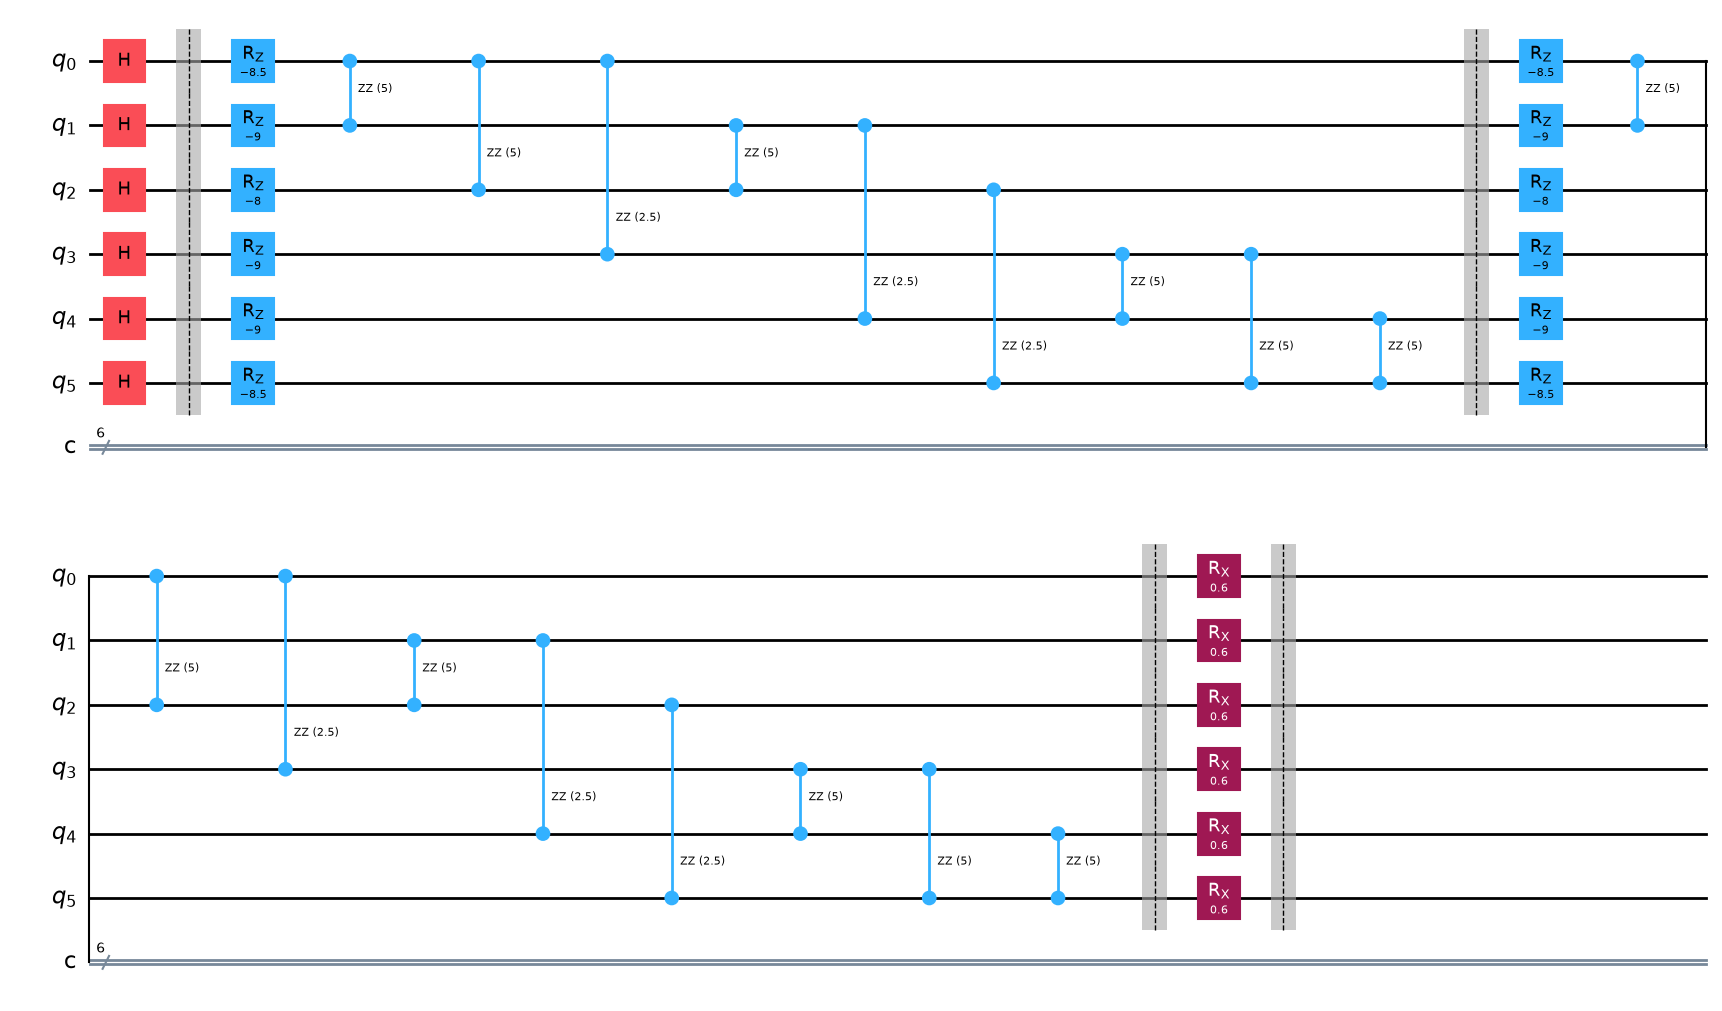

In [23]:
# ==========================================
# 3. Mixer
# ==========================================

for q in range(6):
  qc.rx(2 * beta, q)

qc.barrier()

qc.draw("mpl")

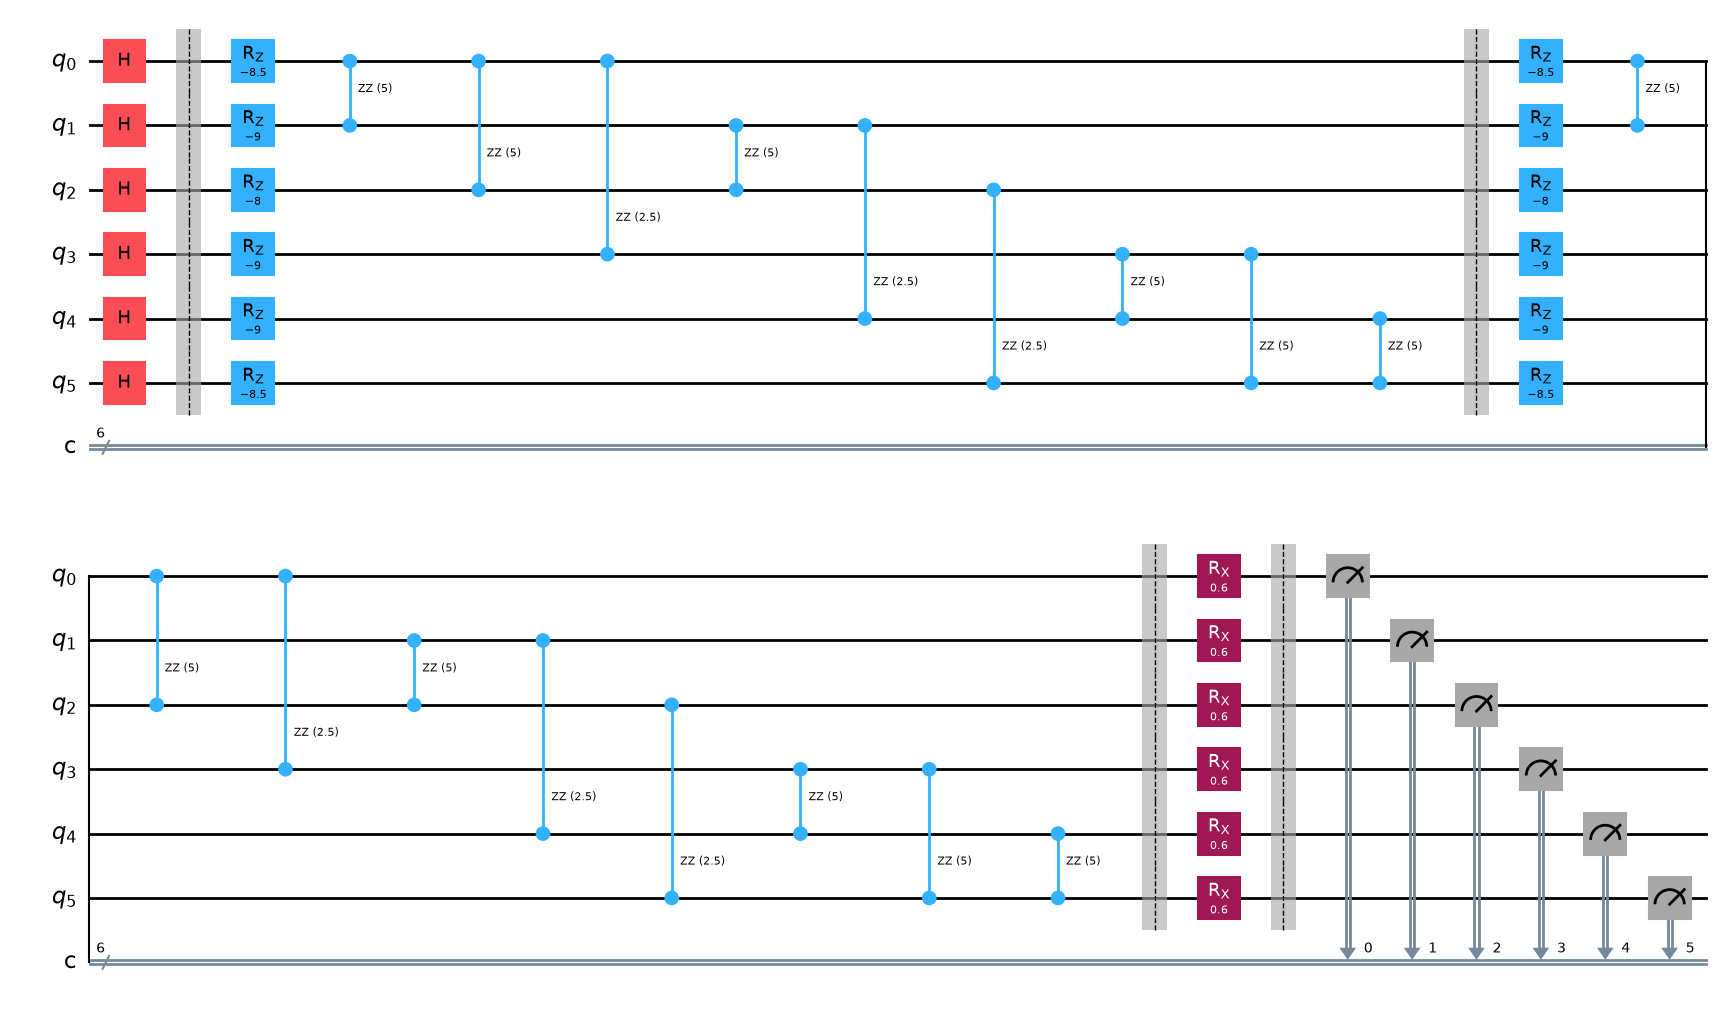

In [24]:
# ==========================================
# 4. Messung
# ==========================================

qc.measure(range(6), range(6))

qc.draw("mpl")


In [ ]:
ket0=Statevector